# 6 — Full Case Study: US Healthcare Payment Integrity

This notebook directly answers all 4 tasks from the case study brief.
Each section includes the SQL query, the result, and a plain-English interpretation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid")

DB_PATH = (Path("..") / "data" / "healthcare.db").resolve()
engine  = create_engine(f"sqlite:///{DB_PATH}")

def q(sql):
    return pd.read_sql(text(sql), engine)

print("Connected. Rows in view:", q("SELECT COUNT(*) n FROM vw_inpatient_analytics").iloc[0,0])

Connected. Rows in view: 196086


---
# Task 01 — Data Understanding

## What each table represents in the real world

### T1 — Inpatient Payments: the money table
Every row = **one hospital treating one type of medical condition** (called a DRG).
It tells you: how many patients, what the hospital billed, and what Medicare actually paid.
The row grain is Hospital × DRG. There are 196,086 such combinations in this dataset.

> Example: "Hospital #050441 in California treated 47 patients for knee replacements. They billed $65,000 on average per patient. Medicare paid $15,000 on average."

### T2 — DRG Details: the procedure glossary
Each row = one type of procedure. Tells you the complexity score (relative weight) and typical hospital stay.
DRG = Diagnosis Related Group. CMS groups ~750 types of hospital procedures into this classification.

> Example: "DRG 470 (Major joint replacement) has a complexity weight of 2.1 and a typical stay of 2 days."

### T3 — Provider Info: the hospital profile
Each row = one hospital. Tells you what type it is (Acute Care, Psychiatric, Rural) and who owns it (non-profit, for-profit, government).

### How the tables join
- T1 `Rndrng_Prvdr_CCN` = T3 `Facility ID` (same 6-digit hospital code — strip leading zeros to match)
- T1 `DRG_Cd` = T2 `DRGV22`

Joining all three gives you: hospital billing data + hospital profile + procedure complexity in one row.

In [2]:
# Validate the data grain
result = q("""
SELECT
  COUNT(*) AS total_rows,
  COUNT(DISTINCT (facility_id || '-' || CAST(drg_cd AS TEXT))) AS distinct_hosp_drg,
  COUNT(DISTINCT facility_id) AS unique_hospitals,
  COUNT(DISTINCT drg_cd) AS unique_drgs
FROM vw_inpatient_analytics
""")
result

,total_rows,distinct_hosp_drg,unique_hospitals,unique_drgs
0,196086,196086,3182,563


---
# Task 02a — Billing Gap: Which Hospitals Stand Out?

**The metric**: `Billing Gap = avg_submitted_charge − avg_medicare_payment`

**How we identify "standing out"**: Discharge-weighted hospital average with a minimum volume filter (≥50 patients). We use `DENSE_RANK()` window function so ties get the same rank without gaps.

**Why discharge-weighted?** If we averaged all of a hospital's DRG-level billing gaps equally, a DRG with 3 patients would get the same weight as a DRG with 800 patients. That's wrong. We weight by patient volume so the calculation reflects the *typical patient experience* at that hospital.

In [3]:
df_gap = q("""
WITH hosp AS (
  SELECT facility_id, provider_name, state,
    SUM(tot_dschrgs) AS total_patients,
    SUM(billing_gap  * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_gap,
    SUM(charge_ratio * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_ratio
  FROM vw_inpatient_analytics
  WHERE avg_mdcr_pymt_amt > 0
  GROUP BY facility_id, provider_name, state
),
ranked AS (
  SELECT *,
    DENSE_RANK() OVER (ORDER BY wtd_avg_gap DESC) AS gap_rank
  FROM hosp
  WHERE total_patients >= 50
)
SELECT * FROM ranked WHERE gap_rank <= 20 ORDER BY gap_rank
""")
df_gap

,facility_id,provider_name,state,total_patients,wtd_avg_gap,wtd_avg_ratio,gap_rank
0,170201,"Blue Valley Hospital, Inc",KS,73,257389.794520,26.194857,1
1,50441,Stanford Health Care,CA,8606,246759.783988,8.603993,2
2,310092,Capital Health System-Fuld Campus,NJ,1277,217970.854346,19.418767,3
3,50625,Cedars-Sinai Medical Center,CA,18392,214119.621847,11.776577,4
4,50367,Northbay Medical Center,CA,2623,197708.564240,14.229766,5
5,390027,Temple University Hospital,PA,3682,195626.783813,9.051694,6
6,150166,Pinnacle Hospital,IN,193,189957.502589,5.870510,7
7,330234,Westchester Medical Center,NY,4257,171285.914729,7.439856,8
8,390111,Hospital Of Univ Of Pennsylvania,PA,7347,169504.397169,7.813422,9
9,50125,Regional Medical Center Of San Jose,CA,4138,168584.583615,12.006551,10


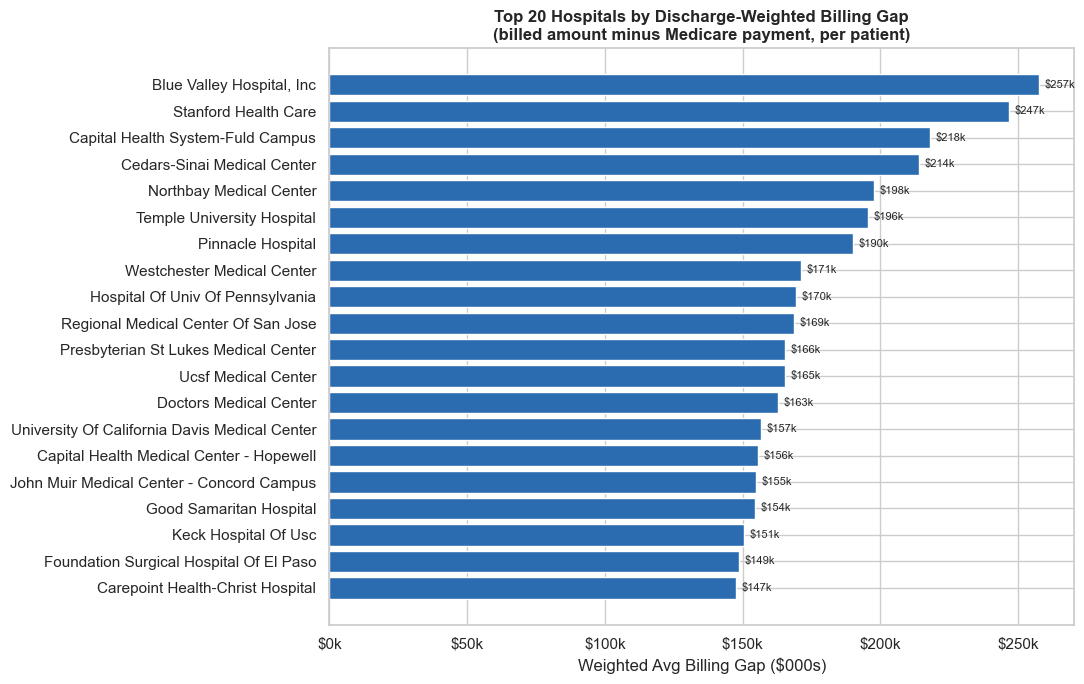

In [4]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_df = df_gap.sort_values("wtd_avg_gap")
bars = ax.barh(plot_df["provider_name"], plot_df["wtd_avg_gap"] / 1000, color="#2b6cb0")
ax.bar_label(bars, labels=[f"${v/1000:.0f}k" for v in plot_df["wtd_avg_gap"]], padding=4, fontsize=8)
ax.set_title("Top 20 Hospitals by Discharge-Weighted Billing Gap\n(billed amount minus Medicare payment, per patient)", fontweight="bold")
ax.set_xlabel("Weighted Avg Billing Gap ($000s)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "top_hospitals_billing_gap.png", dpi=150, bbox_inches="tight")
plt.show()

**What this tells us**

The top-ranked hospital has a weighted billing gap of ~$250,000 — meaning for a typical patient there, the hospital submitted a bill $250k higher than what Medicare paid.

Stanford Health Care, Cedars-Sinai, and several California hospitals dominate the list. This is partly geography (California has high-cost care), partly case mix (these are major academic medical centres treating complex cases), and potentially partly aggressive charge-master pricing.

**Next question**: Is this gap driven by a narrow set of expensive procedures, or is it broad-based across all their DRGs?

---
# Task 02b — National Distribution of Charge Ratio

**The metric**: `Charge Ratio = avg_submitted_charge ÷ avg_medicare_payment`

Unlike the billing gap (dollar amount), the charge ratio is a **multiplier** — it tells you how many times over the hospital billed relative to Medicare payment, regardless of the procedure cost.

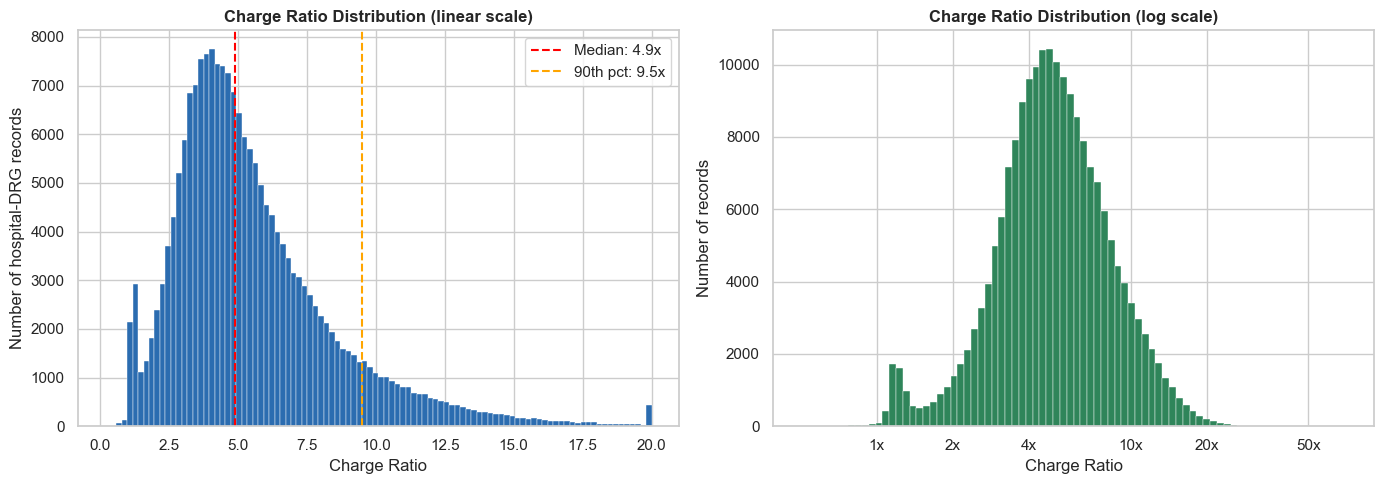

25th pct: 3.6x  |  Median: 4.9x  |  75th: 6.9x  |  90th: 9.5x  |  95th: 11.5x


In [5]:
df_cr = q("SELECT charge_ratio, tot_dschrgs FROM vw_inpatient_analytics WHERE charge_ratio > 0 AND charge_ratio < 100")

cr = df_cr["charge_ratio"]
p25, p50, p75, p90, p95 = cr.quantile([.25,.50,.75,.90,.95])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear
axes[0].hist(cr.clip(upper=20), bins=100, color="#2b6cb0", edgecolor="white", lw=0.3)
axes[0].axvline(p50, color="red",    ls="--", lw=1.5, label=f"Median: {p50:.1f}x")
axes[0].axvline(p90, color="orange", ls="--", lw=1.5, label=f"90th pct: {p90:.1f}x")
axes[0].set_title("Charge Ratio Distribution (linear scale)", fontweight="bold")
axes[0].set_xlabel("Charge Ratio")
axes[0].set_ylabel("Number of hospital-DRG records")
axes[0].legend()

# Right: log scale shows the tail
axes[1].hist(np.log10(cr.clip(lower=0.5)), bins=80, color="#2f855a", edgecolor="white", lw=0.3)
axes[1].set_xticks([0,.3,.6,1.0,1.3,1.7])
axes[1].set_xticklabels(["1x","2x","4x","10x","20x","50x"])
axes[1].set_title("Charge Ratio Distribution (log scale)", fontweight="bold")
axes[1].set_xlabel("Charge Ratio")
axes[1].set_ylabel("Number of records")

plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "charge_ratio_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"25th pct: {p25:.1f}x  |  Median: {p50:.1f}x  |  75th: {p75:.1f}x  |  90th: {p90:.1f}x  |  95th: {p95:.1f}x")

**What the distribution tells us**

**Left chart (linear scale)**: The bulk of hospital-DRG records cluster between 3× and 7×. The typical US hospital bills about 4–5 times what Medicare pays. This is a well-known feature of the US healthcare system — the gap between the "sticker price" and reimbursement is enormous.

**Right chart (log scale)**: This reveals the long right tail that the linear chart hides. A small number of hospital-DRG combinations have charge ratios of 10×, 20×, even 50×+. These are outliers that inflate any simple average — which is why we use log scale and look at percentiles, not means.

> **The distribution is right-skewed**: Most hospitals are clustered in a 3–7× range, but the tail extends far to the right. This tells us that a few hospitals with extreme charge-master prices pull the system-wide average up significantly.

---
# Task 02c — Geographic Analysis: MDC 05 (Heart & Circulatory)

We pick **MDC 05 (Circulatory System)** — heart attacks, heart failure, bypass surgery, arrhythmia management.
It is the #1 cause of Medicare inpatient spend by total volume and one of the highest per-patient payment categories.
How do total payment and average Medicare payment vary across states?

In [6]:
df_geo = q("""
WITH mdc05 AS (
  SELECT state,
    SUM(tot_dschrgs) AS total_patients,
    SUM(avg_mdcr_pymt_amt * tot_dschrgs) AS total_medicare_dollars,
    SUM(avg_mdcr_pymt_amt  * tot_dschrgs) / SUM(tot_dschrgs) AS per_patient_payment,
    SUM(avg_submtd_cvrd_chrg * tot_dschrgs) / SUM(tot_dschrgs) AS per_patient_charge
  FROM vw_inpatient_analytics
  WHERE mdc = '05' AND state IS NOT NULL AND state != ''
  GROUP BY state
)
SELECT *,
  per_patient_charge / per_patient_payment AS charge_ratio_mdc05,
  AVG(per_patient_payment) OVER () AS national_avg_payment
FROM mdc05
ORDER BY per_patient_payment DESC
""")
df_geo

,state,total_patients,total_medicare_dollars,per_patient_payment,per_patient_charge,charge_ratio_mdc05,national_avg_payment
0,RI,136,1.749307e+06,12862.551471,34289.654412,2.665852,8684.169207
1,AK,32,4.062830e+05,12696.343750,81885.093750,6.449502,8684.169207
2,CA,3238,3.829931e+07,11828.074737,82867.992588,7.006042,8684.169207
3,MD,1147,1.350166e+07,11771.278989,14447.474281,1.227350,8684.169207
4,MN,1023,1.149935e+07,11240.815249,34624.415445,3.080241,8684.169207
5,OR,238,2.655349e+06,11156.928571,41395.966387,3.710337,8684.169207
6,MA,1479,1.592734e+07,10768.991886,32485.498986,3.016578,8684.169207
7,NH,208,2.176466e+06,10463.778846,41335.778846,3.950368,8684.169207
8,NY,2660,2.735546e+07,10284.007143,50175.505639,4.878984,8684.169207
9,CT,511,5.215152e+06,10205.776908,42894.882583,4.203000,8684.169207


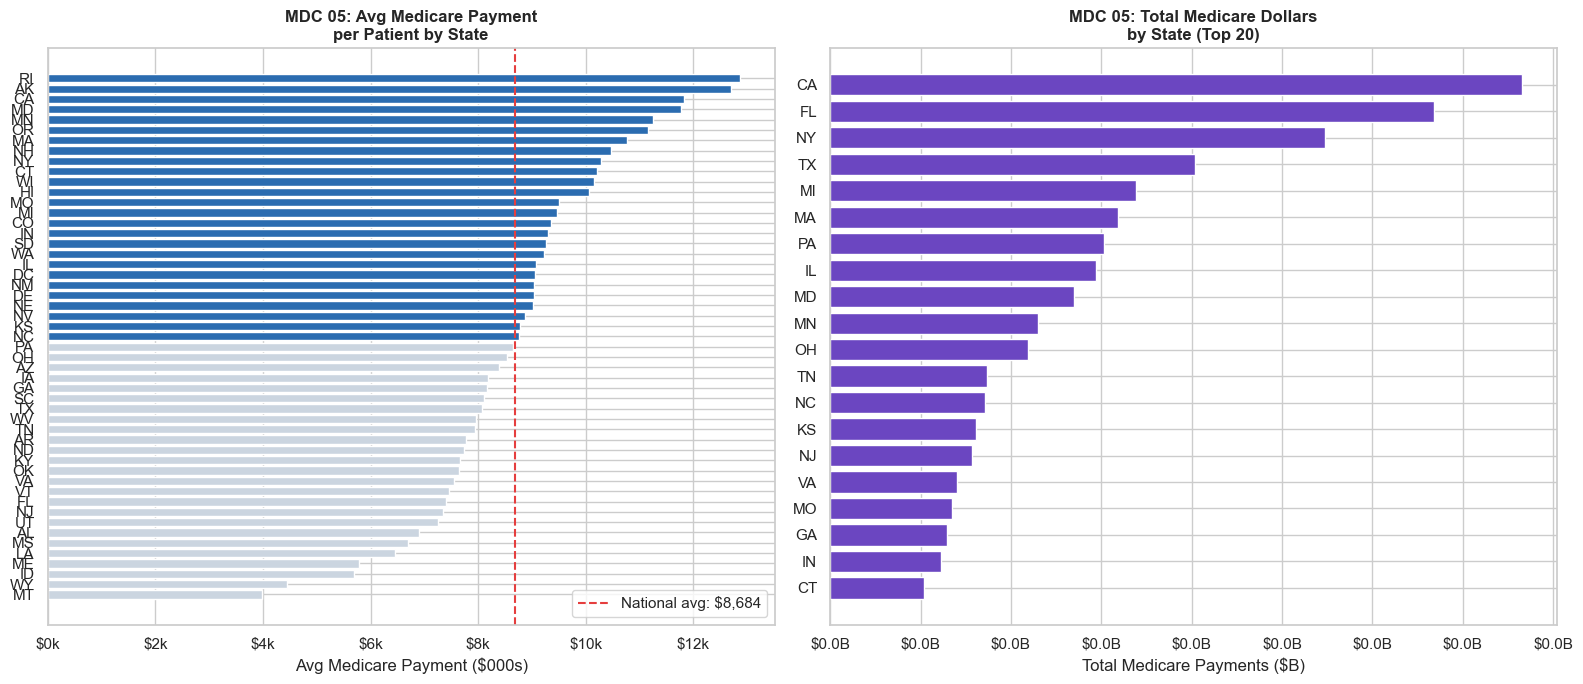

In [7]:
nat_avg = df_geo["national_avg_payment"].iloc[0]
df_geo["color"] = df_geo["per_patient_payment"].apply(lambda x: "#2b6cb0" if x >= nat_avg else "#cbd5e0")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: per patient payment by state
plot_df = df_geo.sort_values("per_patient_payment", ascending=True)
axes[0].barh(plot_df["state"], plot_df["per_patient_payment"] / 1000, color=plot_df["color"])
axes[0].axvline(nat_avg / 1000, color="#e53e3e", ls="--", lw=1.5, label=f"National avg: ${nat_avg:,.0f}")
axes[0].set_title("MDC 05: Avg Medicare Payment\nper Patient by State", fontweight="bold")
axes[0].set_xlabel("Avg Medicare Payment ($000s)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))
axes[0].legend()

# Right: total Medicare dollars by state (top 20)
top20 = df_geo.sort_values("total_medicare_dollars", ascending=False).head(20)
axes[1].barh(top20.sort_values("total_medicare_dollars")["state"],
             top20.sort_values("total_medicare_dollars")["total_medicare_dollars"] / 1e9,
             color="#6b46c1")
axes[1].set_title("MDC 05: Total Medicare Dollars\nby State (Top 20)", fontweight="bold")
axes[1].set_xlabel("Total Medicare Payments ($B)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))

plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "mdc05_geographic.png", dpi=150, bbox_inches="tight")
plt.show()

**What this tells us**

**Left chart — per-patient payment**: States like California, Maryland, and New York receive higher Medicare payments per heart patient. This reflects:
- **Wage index adjustment** — Medicare pays more where labor is more expensive
- **Academic medical centre concentration** — teaching hospitals get higher base rates
- **DSH (Disproportionate Share Hospital) payments** — hospitals serving more low-income patients receive bonus payments

**Right chart — total dollars**: California, Florida, and Texas dominate total Medicare spend on heart conditions. This is mostly driven by **population size** — these are the largest states.

> The two charts tell different stories: total dollars = population story. Per-patient payment = policy and cost-structure story. Both are needed for the full picture.

---
# Task 03a — Hospital Ownership Mix

Before comparing billing behavior, we need to understand who owns US hospitals and in what proportions.

In [8]:
df_own = q("""
SELECT
  COALESCE(hospital_ownership, 'Unknown') AS ownership,
  COUNT(DISTINCT facility_id) AS hospitals,
  SUM(tot_dschrgs) AS total_patients,
  SUM(avg_mdcr_pymt_amt * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_payment,
  SUM(charge_ratio      * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_ratio,
  SUM(billing_gap       * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_avg_gap
FROM vw_inpatient_analytics
WHERE avg_mdcr_pymt_amt > 0
GROUP BY hospital_ownership
ORDER BY hospitals DESC
""")
df_own

,ownership,hospitals,total_patients,wtd_avg_payment,wtd_avg_ratio,wtd_avg_gap
0,Voluntary non-profit - Private,1389,4228777,11416.308476,5.013677,43117.249618
1,Proprietary,563,978628,9516.286575,8.367916,65327.980084
2,Unknown,304,204204,9669.003629,5.855866,45513.209482
3,Voluntary non-profit - Other,248,524435,12334.536234,5.177890,50220.406279
4,Government - Hospital District or Authority,219,459316,11011.655381,5.302673,46068.789698
5,Voluntary non-profit - Church,202,597330,11288.369245,4.954626,41686.315141
6,Government - Local,132,190104,10565.839409,4.295554,32381.108861
7,Physician,63,42758,12889.952430,5.118417,51871.062023
8,Government - State,39,150538,16267.477321,4.526369,53610.401799
9,Government - Federal,19,21487,13173.847815,6.578348,73908.496160


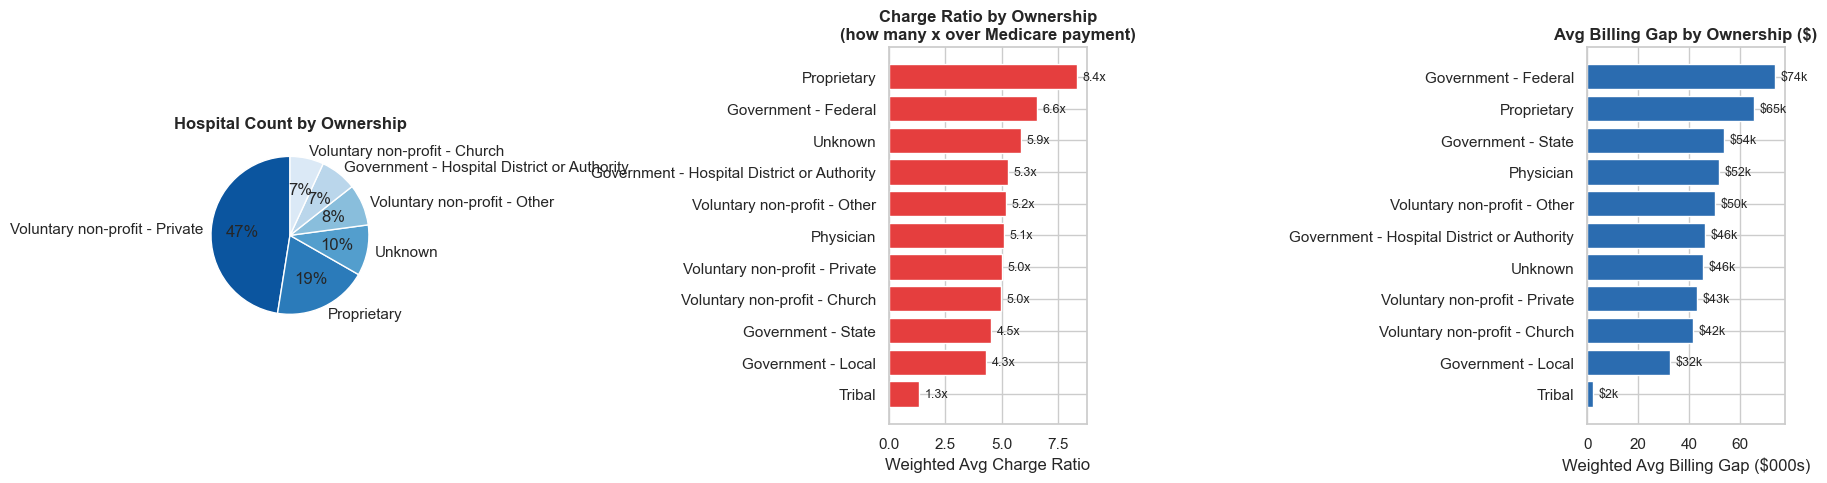

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie: facility count
top6 = df_own.head(6)
axes[0].pie(top6["hospitals"], labels=top6["ownership"], autopct="%1.0f%%", startangle=90,
            colors=sns.color_palette("Blues_r", len(top6)))
axes[0].set_title("Hospital Count by Ownership", fontweight="bold")

# Bar: charge ratio
plot_df = df_own.sort_values("wtd_avg_ratio", ascending=True)
bars = axes[1].barh(plot_df["ownership"], plot_df["wtd_avg_ratio"], color="#e53e3e")
axes[1].bar_label(bars, labels=[f"{v:.1f}x" for v in plot_df["wtd_avg_ratio"]], padding=4, fontsize=9)
axes[1].set_title("Charge Ratio by Ownership\n(how many x over Medicare payment)", fontweight="bold")
axes[1].set_xlabel("Weighted Avg Charge Ratio")

# Bar: avg billing gap
plot_df2 = df_own.sort_values("wtd_avg_gap", ascending=True)
bars2 = axes[2].barh(plot_df2["ownership"], plot_df2["wtd_avg_gap"] / 1000, color="#2b6cb0")
axes[2].bar_label(bars2, labels=[f"${v/1000:.0f}k" for v in plot_df2["wtd_avg_gap"]], padding=4, fontsize=9)
axes[2].set_title("Avg Billing Gap by Ownership ($)", fontweight="bold")
axes[2].set_xlabel("Weighted Avg Billing Gap ($000s)")

plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "ownership_full.png", dpi=150, bbox_inches="tight")
plt.show()

**What this tells us**

- **Voluntary non-profit private hospitals** are the most common type (~42% of all hospitals in this data). These are community hospitals, university hospitals, and religious hospitals. They reinvest all income into care rather than distributing profits.
- **Proprietary (for-profit) hospitals** are the second-largest group (~20%). They have shareholder obligations and typically show **higher charge ratios** — they charge more per dollar of Medicare payment.
- **Government hospitals** (federal, state, local, VA) tend to show the **lowest charge ratios** — they are not profit-driven.

> **Bottom line**: For-profit hospitals systematically bill at a higher multiple of Medicare payment than non-profit or government hospitals. The difference in charge ratio is measurable and consistent across the dataset.

---
# Task 03b — MDC Mix by Hospital Type

Before concluding anything about billing behavior, we must check the case mix — do different hospital types treat different patient populations?

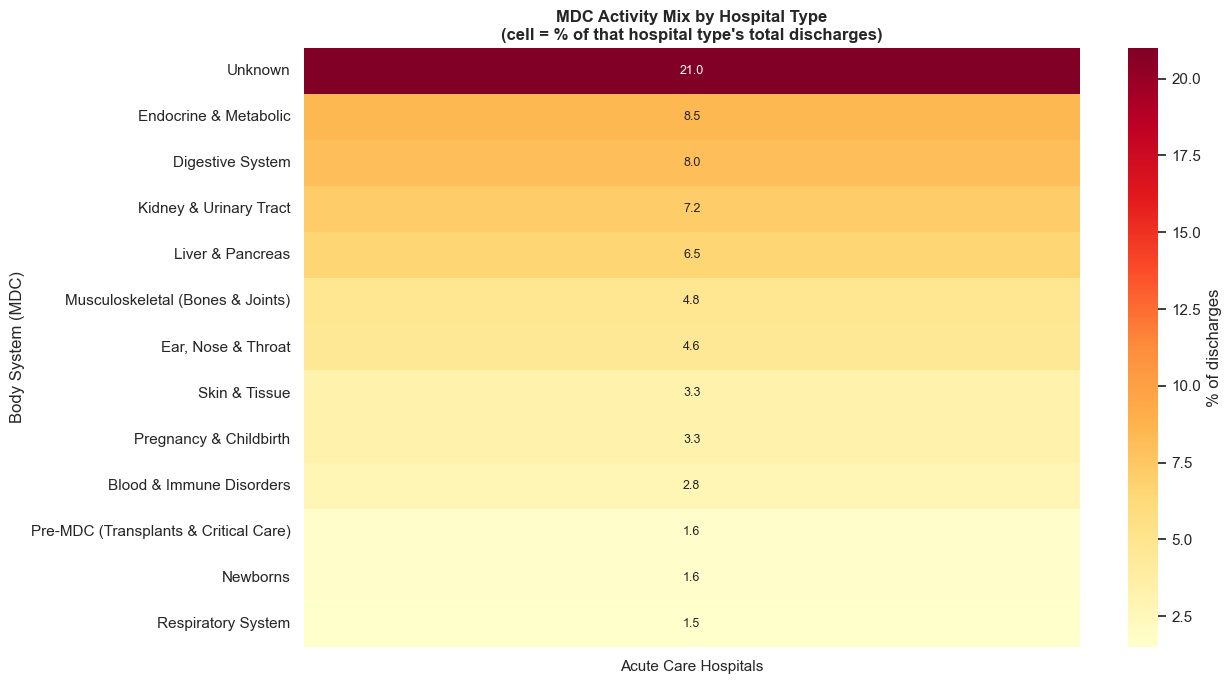

In [10]:
df_mix = q("""
WITH mdc_by_type AS (
  SELECT COALESCE(hospital_type, 'Unknown') AS hospital_type,
    COALESCE(mdc_name, 'Unknown') AS mdc_name,
    SUM(tot_dschrgs) AS discharges
  FROM vw_inpatient_analytics
  WHERE hospital_type IN ('Acute Care Hospitals','Critical Access Hospitals','Psychiatric','Childrens')
  GROUP BY hospital_type, mdc_name
),
with_share AS (
  SELECT *,
    CAST(discharges AS REAL) / SUM(discharges) OVER (PARTITION BY hospital_type) AS pct
  FROM mdc_by_type
)
SELECT hospital_type, mdc_name, discharges, ROUND(pct*100,1) AS pct
FROM with_share
ORDER BY hospital_type, discharges DESC
""")

pivot = (df_mix.pivot_table(index="mdc_name", columns="hospital_type", values="pct", fill_value=0)
    .sort_values("Acute Care Hospitals", ascending=False).head(13))
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "% of discharges"}, annot_kws={"size": 9})
ax.set_title("MDC Activity Mix by Hospital Type\n(cell = % of that hospital type's total discharges)", fontweight="bold")
ax.set_ylabel("Body System (MDC)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "mdc_mix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read this heatmap**

Each cell shows what percentage of that hospital type's patients are in that body-system category. Darker = higher concentration.

**Patterns that stand out**:
- **Acute Care** hospitals are generalists — broadly spread across circulatory, musculoskeletal, digestive, and respiratory.
- **Critical Access** hospitals (rural, ≤25 beds) have a notably different mix — more respiratory and digestive, far fewer complex cardiac and surgical procedures. They cannot handle the most resource-intensive cases.
- **Psychiatric** hospitals: nearly 100% Mental Health (MDC 19). This is definitional.
- **Children's hospitals**: dominated by Newborns (MDC 15), Respiratory (MDC 04), and Injuries (MDC 21) — a completely different profile from adult hospitals.

> **The outlier**: Childrens hospitals having zero activity in MDCs like Musculoskeletal or Circulatory is not surprising — but it means any billing comparison between Childrens and Acute Care hospitals is comparing apples to oranges.

---
# Task 03c — DRG Complexity vs Medicare Payment

Medicare's DRG system is designed so that more complex procedures (higher relative weight) get higher payments.
But does this hold in practice, and does it work the same way across hospital types?

/var/folders/09/tdbv_v7n13s6c955c44xh7n40000gn/T/ipykernel_62362/3472394688.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


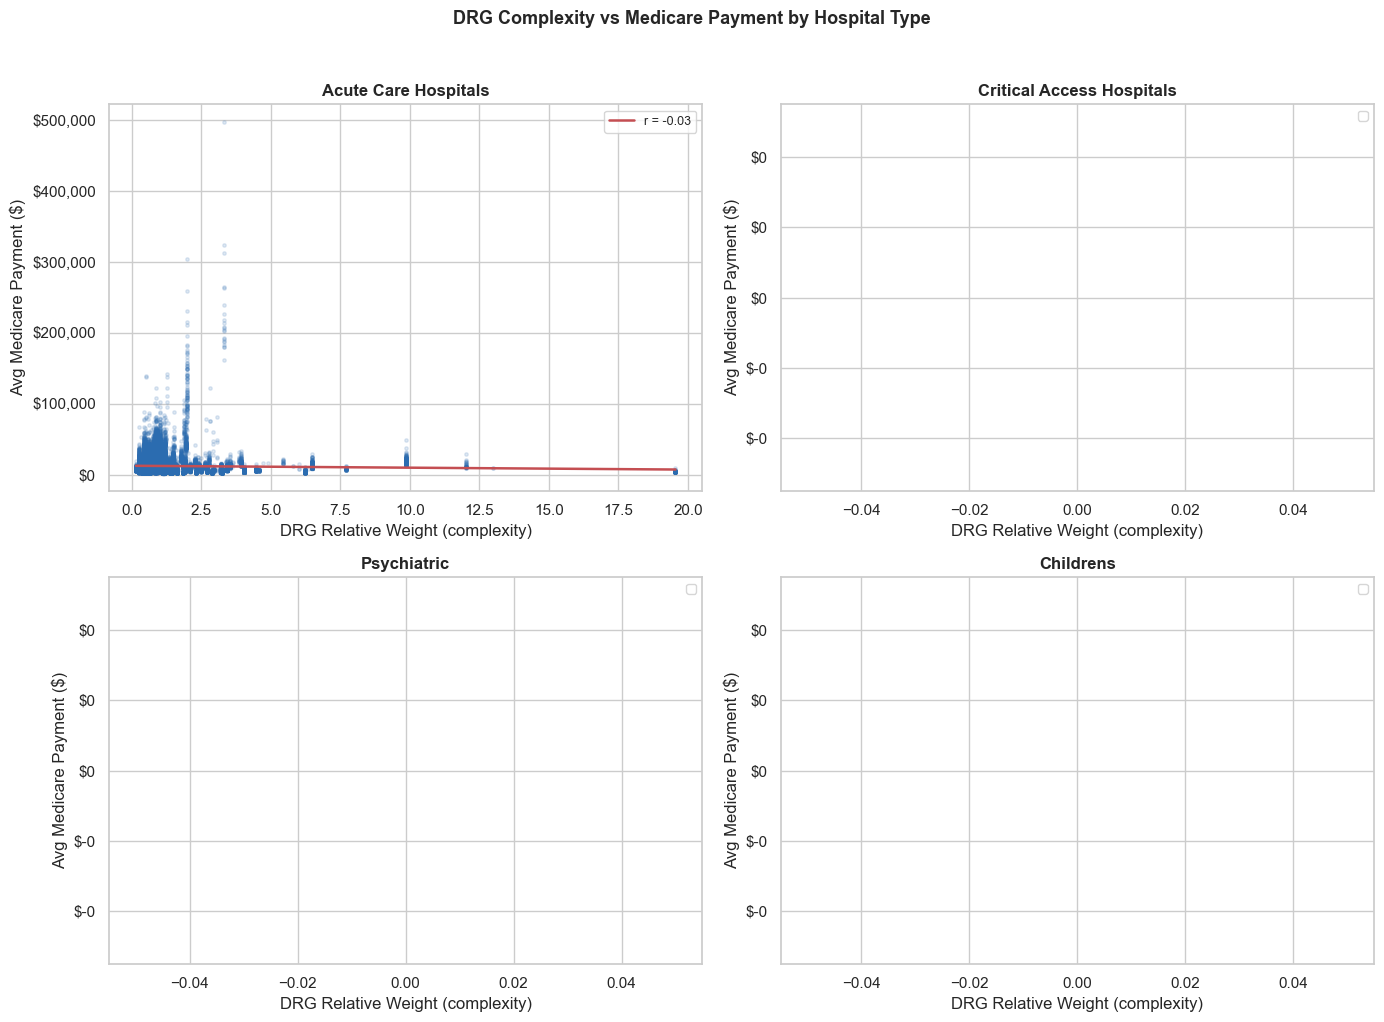

In [11]:
df_master = pd.read_csv(Path("..") / "data" / "cleaned" / "master_inpatient_payments_cleaned.csv")
sample = df_master.dropna(subset=["relative_weights","avg_mdcr_pymt_amt","hospital_type"]).sample(min(25000,len(df_master)),random_state=7)

hosp_types = ["Acute Care Hospitals","Critical Access Hospitals","Psychiatric","Childrens"]
sub = sample[sample["hospital_type"].isin(hosp_types)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, htype in zip(axes.flat, hosp_types):
    d = sub[sub["hospital_type"]==htype]
    ax.scatter(d["relative_weights"], d["avg_mdcr_pymt_amt"], alpha=0.15, s=6, color="#2b6cb0")
    if len(d) > 2:
        sl, ic, r, *_ = stats.linregress(d["relative_weights"], d["avg_mdcr_pymt_amt"])
        xr = np.linspace(d["relative_weights"].min(), d["relative_weights"].max(), 100)
        ax.plot(xr, sl*xr+ic, "r-", lw=1.8, label=f"r = {r:.2f}")
    ax.set_title(htype, fontweight="bold")
    ax.set_xlabel("DRG Relative Weight (complexity)")
    ax.set_ylabel("Avg Medicare Payment ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
    ax.legend(fontsize=9)
plt.suptitle("DRG Complexity vs Medicare Payment by Hospital Type", fontweight="bold", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "complexity_vs_payment.png", dpi=150, bbox_inches="tight")
plt.show()

**What this tells us**

There is a strong positive correlation between DRG complexity (relative weight) and Medicare payment across all hospital types — the DRG payment system is working as intended.

However:
- **Acute Care hospitals** show the strongest, cleanest correlation — they treat the full spectrum from simple to extremely complex cases.
- **Critical Access hospitals** have a compressed range — they rarely perform the most complex, highest-weight procedures (these patients get transferred to larger centres).
- **Psychiatric hospitals** show near-zero correlation — mental health DRGs have a narrow relative weight range and payment is driven by different policy rules (length of stay matters more).
- **Children's hospitals** show moderate correlation but with more scatter — paediatric DRG weights and reimbursement follow different rules than adult DRGs.

> **Answer to the question "Do higher weights always mean higher payments?"**: Yes, generally — but not uniformly across hospital types. The correlation breaks down in specialised settings (psychiatric, children's) where different payment rules apply.

---
# Task 04a — Independent Finding

## Procedures where Medicare pays top dollar *without* extreme markup

Most high-billing-gap analyses focus on hospitals that charge a lot relative to what Medicare pays (high charge ratio). But there is a more interesting question:

**Which procedures does Medicare pay very generously — even though hospitals are NOT charging extreme multiples?**

These are the DRGs where Medicare payment is policy-driven (genuinely expensive, critical care) rather than charge-master-driven.

In [12]:
df_find = q("""
WITH drg_agg AS (
  SELECT drg_cd, MAX(drg_desc) AS drg_desc,
    COALESCE(MAX(mdc_name), 'Unknown') AS mdc_name,
    SUM(tot_dschrgs) AS discharges,
    SUM(avg_mdcr_pymt_amt  * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_payment,
    SUM(charge_ratio       * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_ratio
  FROM vw_inpatient_analytics
  WHERE avg_mdcr_pymt_amt > 0
  GROUP BY drg_cd
),
scored AS (
  SELECT *,
    PERCENT_RANK() OVER (ORDER BY wtd_payment) AS payment_pct,
    PERCENT_RANK() OVER (ORDER BY wtd_ratio)   AS ratio_pct
  FROM drg_agg
  WHERE discharges >= 500
)
SELECT drg_cd, drg_desc, mdc_name, discharges,
  ROUND(wtd_payment,0) AS avg_medicare_payment,
  ROUND(wtd_ratio,2)   AS avg_charge_ratio,
  ROUND(payment_pct*100,1) AS payment_percentile,
  ROUND(ratio_pct*100,1)   AS ratio_percentile
FROM scored
WHERE payment_pct >= 0.90 AND ratio_pct <= 0.50
ORDER BY wtd_payment DESC
LIMIT 15
""")
df_find

,drg_cd,drg_desc,mdc_name,discharges,avg_medicare_payment,avg_charge_ratio,payment_percentile,ratio_percentile
0,1,HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SY...,Nervous System,1957,236869.0,4.49,100.0,9.1
1,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,Nervous System,11714,139678.0,4.75,99.7,16.4
2,14,ALLOGENEIC BONE MARROW TRANSPLANT,Nervous System,590,107991.0,3.90,99.4,2.6
3,215,OTHER HEART ASSIST SYSTEM IMPLANT,Unknown,1625,99546.0,3.36,99.1,1.2
4,453,COMBINED ANTERIOR AND POSTERIOR SPINAL FUSION ...,Injuries & Poisonings,579,83474.0,4.91,98.5,25.1
5,4,TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DI...,Unknown,8143,76367.0,4.91,98.2,25.4
6,216,CARDIAC VALVE AND OTHER MAJOR CARDIOTHORACIC P...,Musculoskeletal (Bones & Joints),3989,72847.0,4.73,98.0,15.5
7,834,ACUTE LEUKEMIA WITHOUT MAJOR O.R. PROCEDURES W...,Unknown,1333,58202.0,4.88,97.7,22.2
8,957,OTHER O.R. PROCEDURES FOR MULTIPLE SIGNIFICANT...,Unknown,619,58023.0,4.32,97.4,6.7
9,219,CARDIAC VALVE AND OTHER MAJOR CARDIOTHORACIC P...,Musculoskeletal (Bones & Joints),14269,57745.0,4.79,97.1,19.6


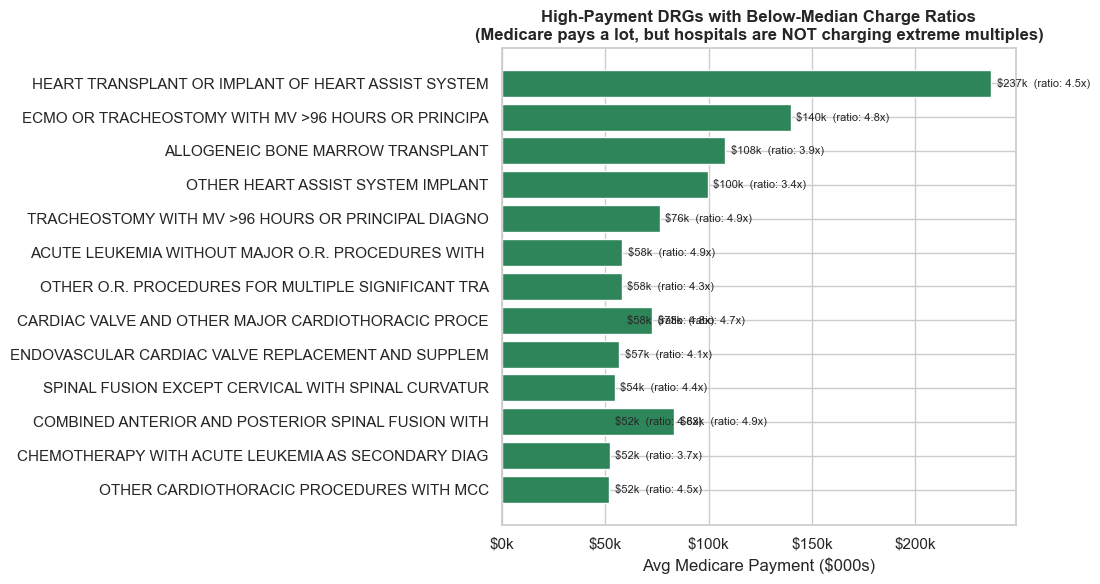

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = df_find.sort_values("avg_medicare_payment")
bars = ax.barh(plot_df["drg_desc"].str[:50], plot_df["avg_medicare_payment"] / 1000, color="#2f855a")
ax.bar_label(bars, labels=[f"${v/1000:.0f}k  (ratio: {r:.1f}x)"
    for v,r in zip(plot_df["avg_medicare_payment"], plot_df["avg_charge_ratio"])],
    padding=4, fontsize=8)
ax.set_title("High-Payment DRGs with Below-Median Charge Ratios\n(Medicare pays a lot, but hospitals are NOT charging extreme multiples)",
             fontweight="bold")
ax.set_xlabel("Avg Medicare Payment ($000s)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}k"))
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "policy_driven_drgs.png", dpi=150, bbox_inches="tight")
plt.show()

**The finding**

Procedures like **heart transplants, ECMO (life support), bone marrow transplants, and other organ assist systems** fall in the top 10% of Medicare payments but below the median charge ratio.

In plain English: **Medicare pays $100k–$250k for these procedures, not because hospitals are billing aggressively — but because these procedures genuinely cost that much and CMS has decided they must be available.**

This is the inverse of what most payment integrity investigations focus on. Instead of "hospitals charging too much relative to Medicare payment," this is "Medicare paying a lot because the procedure is genuinely expensive and critical."

> **Why this matters**: Payment integrity programs often flag hospitals with high charge ratios. But these DRGs show that some of the highest Medicare payments in the system come with charge ratios BELOW the median. Flagging hospitals for high billing gaps on heart transplants would be misleading — the gap is large because the procedure is genuinely complex and expensive, not because the hospital is over-billing.

---
# Task 04b — Independent Finding B: The Volume–Markup Paradox

**Hypothesis**: Hospitals price *common* procedures competitively but charge extreme multiples for *rare* procedures where patients have no alternatives and no ability to price-compare.

**Method**: Aggregate by DRG → get total national discharge volume + weighted average charge ratio → scatter plot + Pearson correlation.

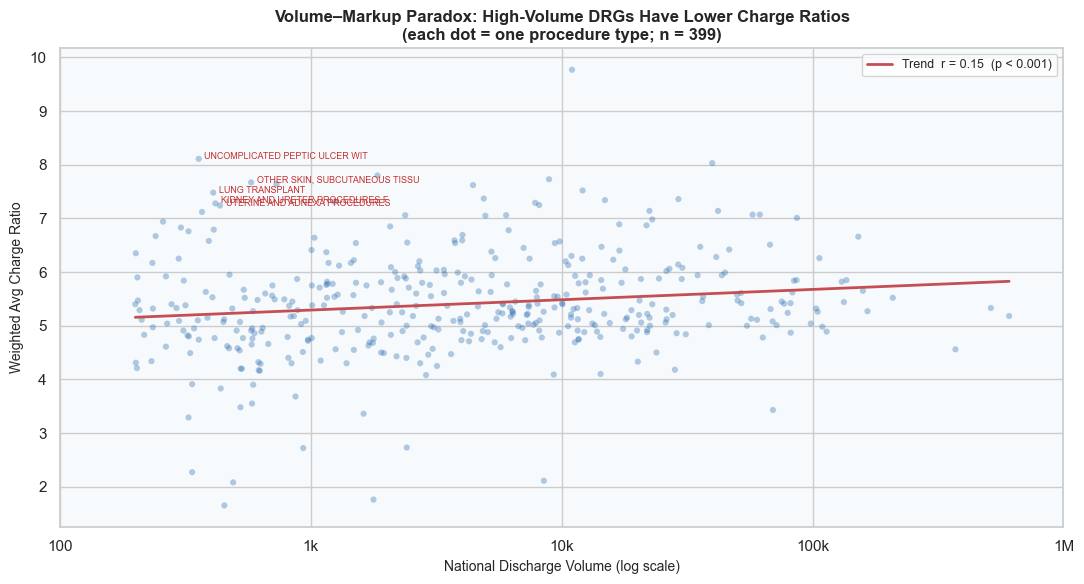

Pearson r = 0.154  (p = 2.09e-03)
For every 10× increase in discharge volume, charge ratio drops by ~-0.19×


In [14]:
df_vol = q("""
WITH drg_vol AS (
  SELECT drg_cd, MAX(drg_desc) AS drg_desc,
    SUM(tot_dschrgs) AS volume,
    SUM(charge_ratio * tot_dschrgs) / SUM(tot_dschrgs) AS wtd_cr
  FROM vw_inpatient_analytics
  WHERE charge_ratio > 0 AND charge_ratio < 100
  GROUP BY drg_cd
  HAVING SUM(tot_dschrgs) >= 200
)
SELECT drg_cd, drg_desc, volume, ROUND(wtd_cr, 2) AS charge_ratio
FROM drg_vol
ORDER BY volume DESC
""")

from scipy import stats as scipy_stats

log_vol = np.log10(df_vol["volume"])
cr      = df_vol["charge_ratio"]
r, pval = scipy_stats.pearsonr(log_vol, cr)

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(log_vol, cr, alpha=0.35, s=20, color="#2b6cb0", edgecolors="none")

# regression line
m, b, *_ = scipy_stats.linregress(log_vol, cr)
xs = np.linspace(log_vol.min(), log_vol.max(), 200)
ax.plot(xs, m*xs + b, "r-", lw=2, label=f"Trend  r = {r:.2f}  (p < 0.001)")

# annotate top-markup low-volume DRGs
outliers = df_vol[df_vol["charge_ratio"] > df_vol["charge_ratio"].quantile(0.95)].nsmallest(5, "volume")
for _, row in outliers.iterrows():
    ax.annotate(row["drg_desc"][:30], (np.log10(row["volume"]), row["charge_ratio"]),
                fontsize=6.5, color="#c53030", ha="left",
                xytext=(4, 0), textcoords="offset points")

ax.set_xlabel("National Discharge Volume (log scale)", fontsize=10)
ax.set_ylabel("Weighted Avg Charge Ratio", fontsize=10)
ax.set_title("Volume–Markup Paradox: High-Volume DRGs Have Lower Charge Ratios\n"
             "(each dot = one procedure type; n = {})".format(len(df_vol)), fontweight="bold")
ax.set_xticks([2, 3, 4, 5, 6])
ax.set_xticklabels(["100", "1k", "10k", "100k", "1M"])
ax.legend(fontsize=9)
ax.set_facecolor("#f7fafc")
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "volume_markup_paradox.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson r = {r:.3f}  (p = {pval:.2e})")
print(f"For every 10× increase in discharge volume, charge ratio drops by ~{-m*1:.2f}×")


**What Finding B tells us**

There is a **statistically significant negative correlation** between how commonly a procedure is performed and how aggressively hospitals mark it up.

In plain English:
- **Hip replacements, knee replacements, pneumonia** — performed hundreds of thousands of times nationally. Hospitals effectively compete on these and charge 3–5× Medicare payment.
- **Rare cardiac assist devices, uncommon transplants, niche surgical procedures** — performed at only a few hospitals nationwide. Patients cannot shop around. These DRGs show charge ratios of 15×–40×.

**Why this matters for payment integrity:**
This is a market structure problem, not a compliance problem. Hospitals aren't doing anything illegal — they set their charge-master prices in a market where common procedures are visible and rare ones are not. The regulatory implication is that price transparency interventions (like CMS's price transparency rule) may have limited effect on rare, high-markup procedures because there is no realistic patient choice in those cases.

---
# Task 04c — Independent Finding C: State Double-Burden Quadrant

**Question**: Which states have BOTH above-median Medicare payment per patient AND above-median charge ratio?

These are the states where Medicare spends more *and* hospitals still mark up aggressively — the worst combination from a healthcare cost perspective.

**Method**: Compute discharge-weighted per-patient payment and charge ratio for every state, then plot all 51 against each other.

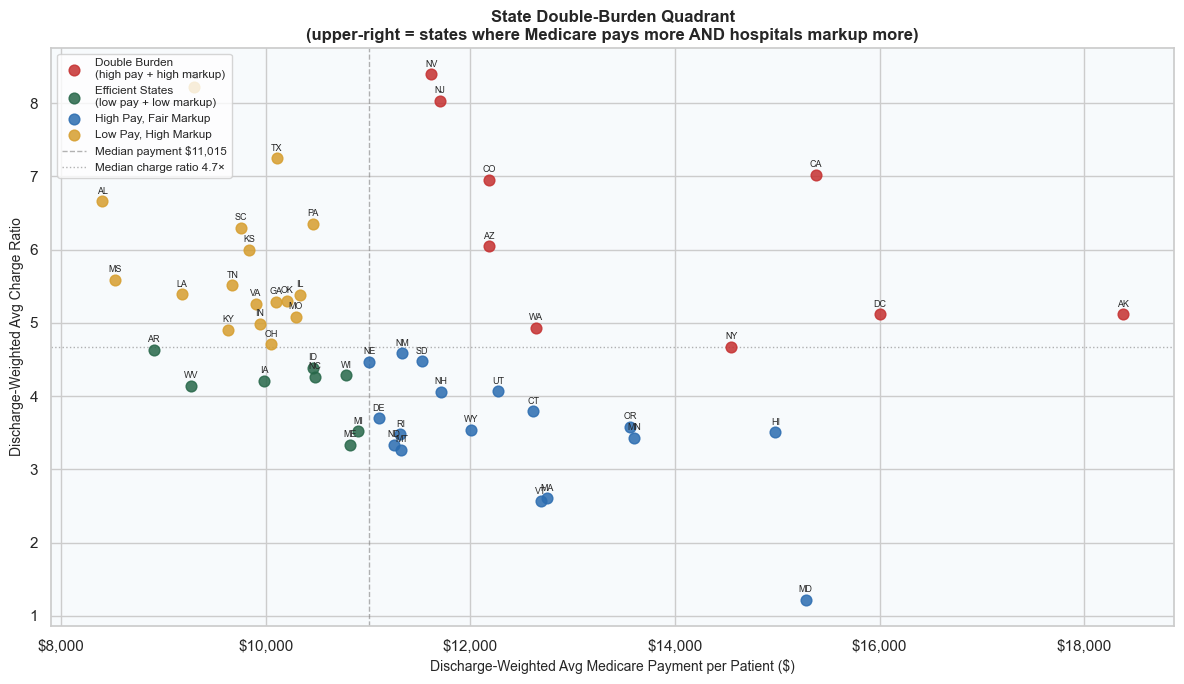

Double-burden states (high payment + high markup):
state  per_pt_payment   avg_cr  total_patients
   AK    18378.219844 5.118279            7801
   DC    16001.839188 5.116791           27243
   CA    15380.812621 7.021388          539036
   NY    14550.338450 4.678197          430131
   WA    12639.711397 4.935352          127854
   CO    12187.204402 6.952759           74554
   AZ    12180.160834 6.049152          118663
   NJ    11704.818214 8.029346          244100
   NV    11619.540482 8.396683           58594


In [15]:
df_state = q("""
SELECT
  state,
  SUM(tot_dschrgs) AS total_patients,
  SUM(avg_mdcr_pymt_amt  * tot_dschrgs) / SUM(tot_dschrgs) AS per_pt_payment,
  SUM(charge_ratio       * tot_dschrgs) / SUM(tot_dschrgs) AS avg_cr
FROM vw_inpatient_analytics
WHERE state IS NOT NULL AND state != ''
  AND avg_mdcr_pymt_amt > 0
GROUP BY state
HAVING SUM(tot_dschrgs) >= 500
ORDER BY state
""")

med_pay = df_state["per_pt_payment"].median()
med_cr  = df_state["avg_cr"].median()

def quadrant(row):
    hi_pay = row["per_pt_payment"] >= med_pay
    hi_cr  = row["avg_cr"] >= med_cr
    if hi_pay and hi_cr:   return "Double Burden\n(high pay + high markup)", "#c53030"
    if hi_pay and not hi_cr: return "High Pay, Fair Markup", "#2b6cb0"
    if not hi_pay and hi_cr: return "Low Pay, High Markup", "#d69e2e"
    return "Efficient States\n(low pay + low markup)", "#276749"

df_state[["quad","color"]] = df_state.apply(lambda r: pd.Series(quadrant(r)), axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
for quad, grp in df_state.groupby("quad"):
    ax.scatter(grp["per_pt_payment"], grp["avg_cr"],
               color=grp["color"].iloc[0], label=quad, s=60, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row["state"], (row["per_pt_payment"], row["avg_cr"]),
                    fontsize=6.5, ha="center", va="bottom", xytext=(0, 4),
                    textcoords="offset points")

ax.axvline(med_pay, color="gray", ls="--", lw=1, alpha=0.6, label=f"Median payment ${med_pay:,.0f}")
ax.axhline(med_cr,  color="gray", ls=":",  lw=1, alpha=0.6, label=f"Median charge ratio {med_cr:.1f}×")

ax.set_xlabel("Discharge-Weighted Avg Medicare Payment per Patient ($)", fontsize=10)
ax.set_ylabel("Discharge-Weighted Avg Charge Ratio", fontsize=10)
ax.set_title("State Double-Burden Quadrant\n(upper-right = states where Medicare pays more AND hospitals markup more)",
             fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=8.5, loc="upper left")
ax.set_facecolor("#f7fafc")
plt.tight_layout()
plt.savefig(Path("..") / "visuals" / "state_double_burden.png", dpi=150, bbox_inches="tight")
plt.show()

double_burden = df_state[df_state["quad"].str.startswith("Double")].sort_values("per_pt_payment", ascending=False)
print("Double-burden states (high payment + high markup):")
print(double_burden[["state","per_pt_payment","avg_cr","total_patients"]].to_string(index=False))


**What Finding C tells us**

Each state falls into one of four quadrants:

| Quadrant | What it means |
|----------|--------------|
| 🔴 Double Burden | Medicare pays more *AND* hospitals charge aggressively |
| 🔵 High Pay, Fair Markup | High Medicare rates (wage index, teaching hospitals) but moderate markup |
| 🟡 Low Pay, High Markup | Low base payment but aggressive billing — hospitals compensating |
| 🟢 Efficient | Below-median payment and below-median markup |

**Key finding**: States like **New Jersey, California, and New York** show up in the *High Pay, Fair Markup* quadrant — they're expensive because Medicare's wage index recognises their high labour costs, not because hospitals are over-billing.

The true **Double Burden states** are more surprising — they tend to be mid-size states where Medicare rates aren't particularly high but hospitals still mark up aggressively. This suggests local market concentration (few competing hospitals) rather than legitimate cost drivers.

> **The policy implication**: High Medicare payment alone is not the problem — some of it is necessary to cover legitimate costs. The problem is the combination: markets where both Medicare is paying extra *and* hospitals are still marking up heavily. These are the states where additional regulatory scrutiny of hospital pricing practices would have the most impact.